In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import matplotlib.patches as patches
from PIL import Image
import matplotlib.patheffects as pe
from scipy import stats
from scipy.spatial.distance import jensenshannon
from patch_analysis.ds_utils import get_genderMap


In [6]:
male_parquet_path = Path('/weka/eickhoff/esx139/patch_analysis/ablation_results/style0/polarity1/ablation_results_male_bg.parquet')
female_parquet_path = Path('/weka/eickhoff/esx139/patch_analysis/ablation_results/style0/polarity1/ablation_results_female_bg.parquet')

IMG_ROOT = Path('/weka/eickhoff/esx139/flux_inpainting/flux_klein/consistent_set/qwen8/style0/cat_2/polarity1')
MERGE_SIZE = 2

gender_map = get_genderMap()



In [12]:
gender_map

{'03_29_1304_2_02': {'A': 'M', 'B': None, 'C': 'F'},
 '03_45_4664_2_03': {'A': 'M', 'B': 'F', 'C': None},
 '03_26_0712_2_02': {'A': 'M', 'B': None, 'C': 'F'},
 '03_38_3138_1_01': {'A': 'F', 'B': None, 'C': 'M'},
 '03_31_1696_2_01': {'A': None, 'B': 'M', 'C': 'F'},
 '03_42_3970_1_03': {'A': 'F', 'B': None, 'C': 'M'},
 '03_18_0604_2_03': {'A': None, 'B': 'M', 'C': 'F'},
 '03_41_3784_2_02': {'A': 'F', 'B': 'M', 'C': None},
 '03_15_0336_2_03': {'A': 'M', 'B': None, 'C': 'F'},
 '03_29_1284_2_02': {'A': 'F', 'B': None, 'C': 'M'},
 '03_38_3264_2_02': {'A': 'M', 'B': None, 'C': 'F'},
 '03_46_4674_1_02': {'A': 'M', 'B': 'F', 'C': None},
 '03_41_3842_1_01': {'A': None, 'B': 'F', 'C': 'M'},
 '03_41_3708_2_03': {'A': 'M', 'B': None, 'C': 'F'},
 '03_41_3782_1_01': {'A': 'M', 'B': 'F', 'C': None},
 '03_39_3324_2_03': {'A': 'F', 'B': None, 'C': 'M'},
 '03_26_0680_2_02': {'A': None, 'B': 'F', 'C': 'M'},
 '03_42_3876_2_02': {'A': None, 'B': 'F', 'C': 'M'},
 '03_34_2276_2_02': {'A': 'F', 'B': None, 'C':

In [ ]:
def load_image(sample_id, bg_style):
    """Edit this to match your naming convention."""
    path = f"{IMG_ROOT}/{sample_id}/{bg_style}.png"
    return Image.open(path)

def downsample_image(img: Image.Image, short_side=1536):
    W, H = img.size

    # already small enough
    if min(W, H) <= short_side:
        return img

    scale = short_side / min(W, H)
    new_W = int(W * scale)
    new_H = int(H * scale)

    return img.resize((new_W, new_H), Image.Resampling.LANCZOS)

BUCKET_EDGES = [-0.5, -0.2, -0.1, -0.05, 0.05, 0.1, 0.2, 0.5, 1.0]
BUCKET_LABELS = ["<-0.5", "-0.2", "-0.1", "-0.05", "~0", "+0.05", "+0.1", "+0.2", "+0.5", ">+0.5"]

def bucketize(val):
    """Return label for the bucket this value falls into."""
    for i, edge in enumerate(BUCKET_EDGES):
        if val < edge:
            return BUCKET_LABELS[i]
    return BUCKET_LABELS[-1]

def build_delta_heatmap(sample_df, grid_h, grid_w, agg='max', percentile=95):
    from collections import defaultdict
    cell_deltas = defaultdict(list)
    
    for _, row in sample_df.iterrows():
        r, c = row['win_row'], row['win_col']
        ws = row['win_size']
        for i in range(r, r + ws):
            for j in range(c, c + ws):
                if i < grid_h and j < grid_w:
                    cell_deltas[(i, j)].append(row['delta'])
    
    heatmap = np.zeros((grid_h, grid_w))
    for (i, j), deltas in cell_deltas.items():
        if agg == 'max':
            heatmap[i, j] = max(deltas)
        elif agg == 'percentile':
            heatmap[i, j] = np.percentile(deltas, percentile)
    
    return heatmap

def overlay_heatmap(img, heatmap, merge_size, title="", ax=None, vmax=None):
    img_w, img_h = img.size
    heatmap = heatmap.copy()
    heatmap[np.abs(heatmap) < 0.05] = 0.0

    heatmap_full = np.repeat(np.repeat(heatmap, merge_size, axis=0), merge_size, axis=1)
    heatmap_img = np.array(Image.fromarray(heatmap_full).resize((img_w, img_h), Image.NEAREST))

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    if vmax is None:
        vmax = max(abs(heatmap_img.min()), abs(heatmap_img.max()))
    if vmax == 0:
        vmax = 1e-10

    ax.imshow(img)
    alpha_map = np.clip(np.abs(heatmap_img) / vmax, 0, 1) * 0.85
    rgba = plt.cm.coolwarm((heatmap_img + vmax) / (2 * vmax))
    rgba[..., 3] = alpha_map
    ax.imshow(rgba)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
    return ax

def plot_sample_comparison(sample_id, df1, df2, style1_name="male_bg", style2_name="female_bg"):
    img1 = downsample_image(load_image(sample_id, style1_name))
    img2 = downsample_image(load_image(sample_id, style2_name))

    s1 = df1[df1['sample_id'] == sample_id]
    s2 = df2[df2['sample_id'] == sample_id]
    if s1.empty or s2.empty:
        raise ValueError(f"Sample {sample_id} not found in one or both dataframes.")

    grid_h = s1['grid_h'].iloc[0]
    grid_w = s1['grid_w'].iloc[0]

    h1 = build_delta_heatmap(s1, grid_h, grid_w)
    h2 = build_delta_heatmap(s2, grid_h, grid_w)

    vmax = max(abs(h1).max(), abs(h2).max())

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
    overlay_heatmap(img1, h1, MERGE_SIZE, title=style1_name, ax=axes[0], vmax=vmax)
    overlay_heatmap(img2, h2, MERGE_SIZE, title=style2_name, ax=axes[1], vmax=vmax)

    sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(-vmax, vmax))
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='vertical',
                        fraction=0.015, pad=0.06, shrink=0.8)                # fixed
    cbar.set_label('Δ prob (clean − ablated)', fontsize=12)

    fig.suptitle(f"Sample: {sample_id}", fontsize=14, fontweight='bold')
    #plt.show()
    return fig, axes



In [8]:
df1 = pd.read_parquet(male_parquet_path)
df2 = pd.read_parquet(female_parquet_path)

# check what the prob dicts look like
print(df1['clean_probs'].iloc[0])
print(df1['ablated-probs'].iloc[0])

{'A': 0.000766754150390625, 'B': 0.953125, 'C': 0.04736328125}
{'A': 0.0004291534423828125, 'B': 0.87890625, 'C': 0.119140625}


In [5]:
df1.columns

Index(['sample_id', 'variant', 'grid_h', 'grid_w', 'win_size', 'frac',
       'stride', 'win_row', 'win_col', 'clean_probs', 'text-only_probs',
       'ablated-probs', 'correct_answer'],
      dtype='object')

In [6]:
def add_flip_col(df):

    df['clean_top1'] = df['clean_probs'].apply(lambda d: max(d, key=d.get))
    df['ablated_top1'] = df['ablated-probs'].apply(lambda d: max(d, key=d.get))
    df['flipped'] = df['clean_top1'] != df['ablated_top1']
    return df

df1 = add_flip_col(df1)
df2 = add_flip_col(df2)

# quick check: how many flips per style?
print("Style 1 flips:", df1['flipped'].sum(), "/", len(df1))
print("Style 2 flips:", df2['flipped'].sum(), "/", len(df2))

Style 1 flips: 123 / 4029
Style 2 flips: 93 / 4029


In [10]:
def add_delta_col(df):
    def compute_delta(row):
        clean = row['clean_probs']
        ablated = row['ablated-probs']
        top1 = max(clean, key=clean.get)  # e.g. 'A'
        return clean[top1] - ablated[top1]
    
    df['clean_top1'] = df['clean_probs'].apply(lambda d: max(d, key=d.get))
    df['delta'] = df.apply(compute_delta, axis=1)
    return df

df1 = add_delta_col(df1)
df2 = add_delta_col(df2)

print(df1['delta'].describe())
print(df2['delta'].describe())

count    4029.000000
mean        0.007887
std         0.082023
min        -0.410156
25%         0.000000
50%         0.000000
75%         0.003906
max         0.856445
Name: delta, dtype: float64
count    4029.000000
mean        0.006603
std         0.078079
min        -0.433594
25%         0.000000
50%         0.000000
75%         0.000000
max         0.845459
Name: delta, dtype: float64


In [8]:
def add_jsd_col(df):
    def compute_jsd(row):
        clean = row['clean_probs']
        ablated = row['ablated-probs']

        keys = sorted(set(clean) | set(ablated))
        p = np.array([clean.get(k, 0.0) for k in keys], dtype=float)
        q = np.array([ablated.get(k, 0.0) for k in keys], dtype=float)

        p = p / p.sum()
        q = q / q.sum()

        # scipy returns Jensen-Shannon distance; square it to get divergence
        return jensenshannon(p, q, base=2) ** 2

    df['jsd'] = df.apply(compute_jsd, axis=1)
    return df

df1 = add_jsd_col(df1)
df2 = add_jsd_col(df2)

print(df1['jsd'].describe())
print(df2['jsd'].describe())


count    4029.000000
mean        0.007375
std         0.037464
min         0.000000
25%         0.000003
50%         0.000066
75%         0.001900
max         0.672130
Name: jsd, dtype: float64
count    4.029000e+03
mean     6.852456e-03
std      3.656090e-02
min      0.000000e+00
25%      9.923019e-07
50%      3.706039e-05
75%      9.740817e-04
max      6.450681e-01
Name: jsd, dtype: float64


In [9]:
def window_to_image_coords(row, img_h, img_w, merge_size=2):
    # grid is post-merge, so effective patch count is grid * merge_size
    patches_h = row['grid_h'] * merge_size
    patches_w = row['grid_w'] * merge_size
    
    cell_h = img_h / patches_h
    cell_w = img_w / patches_w
    
    # window is in grid (merged) coords, so scale by merge_size
    y0 = row['win_row'] * merge_size * cell_h
    x0 = row['win_col'] * merge_size * cell_w
    y1 = y0 + row['win_size'] * merge_size * cell_h
    x1 = x0 + row['win_size'] * merge_size * cell_w
    
    return int(x0), int(y0), int(x1), int(y1)

answer_gender (C): F


(<Figure size 1800x700 with 3 Axes>,
 array([<Axes: title={'center': 'male_bg'}>,
        <Axes: title={'center': 'female_bg'}>], dtype=object))

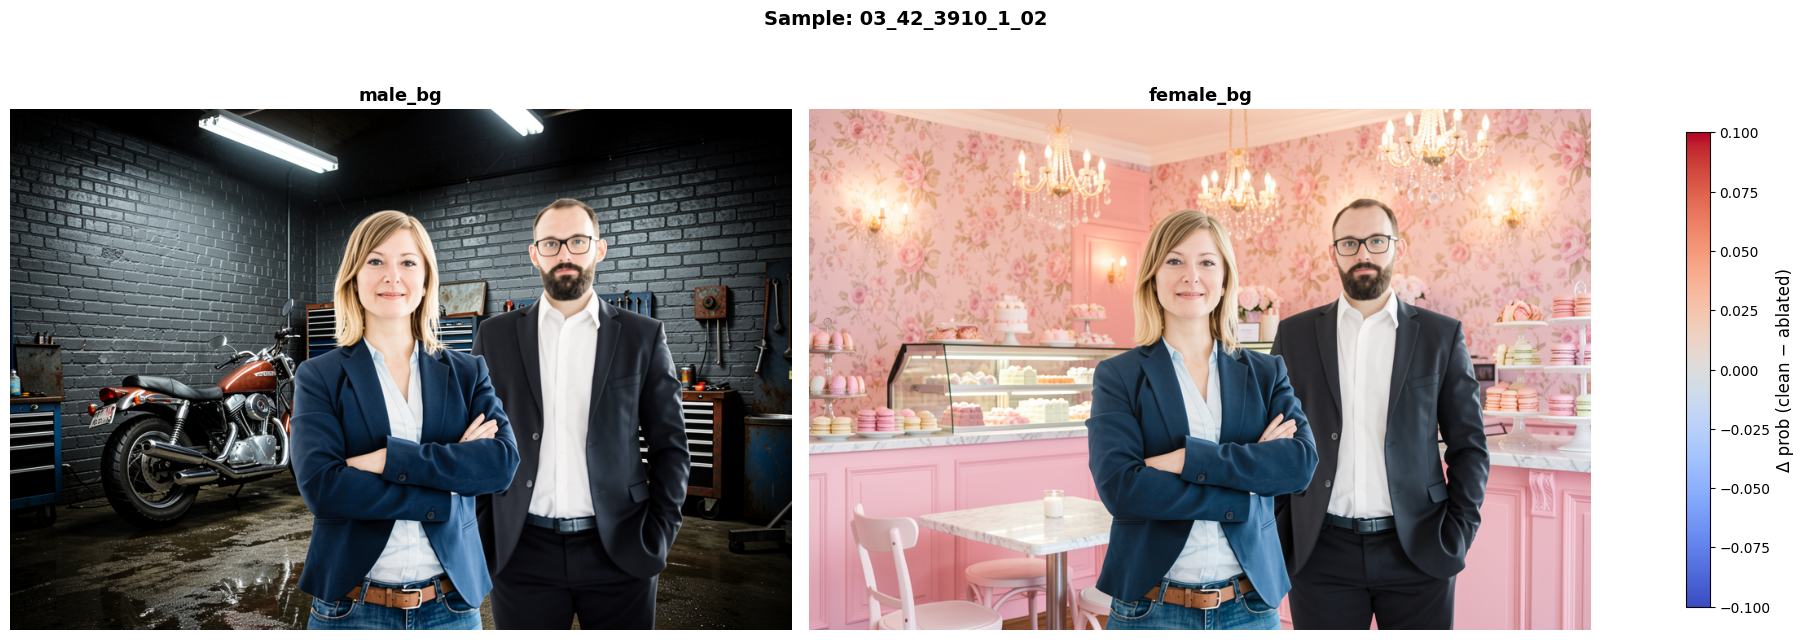

In [11]:
plot_sample_comparison("03_42_3910_1_02", df1, df2)

(<Figure size 1800x700 with 3 Axes>,
 array([<Axes: title={'center': 'male_bg'}>,
        <Axes: title={'center': 'female_bg'}>], dtype=object))

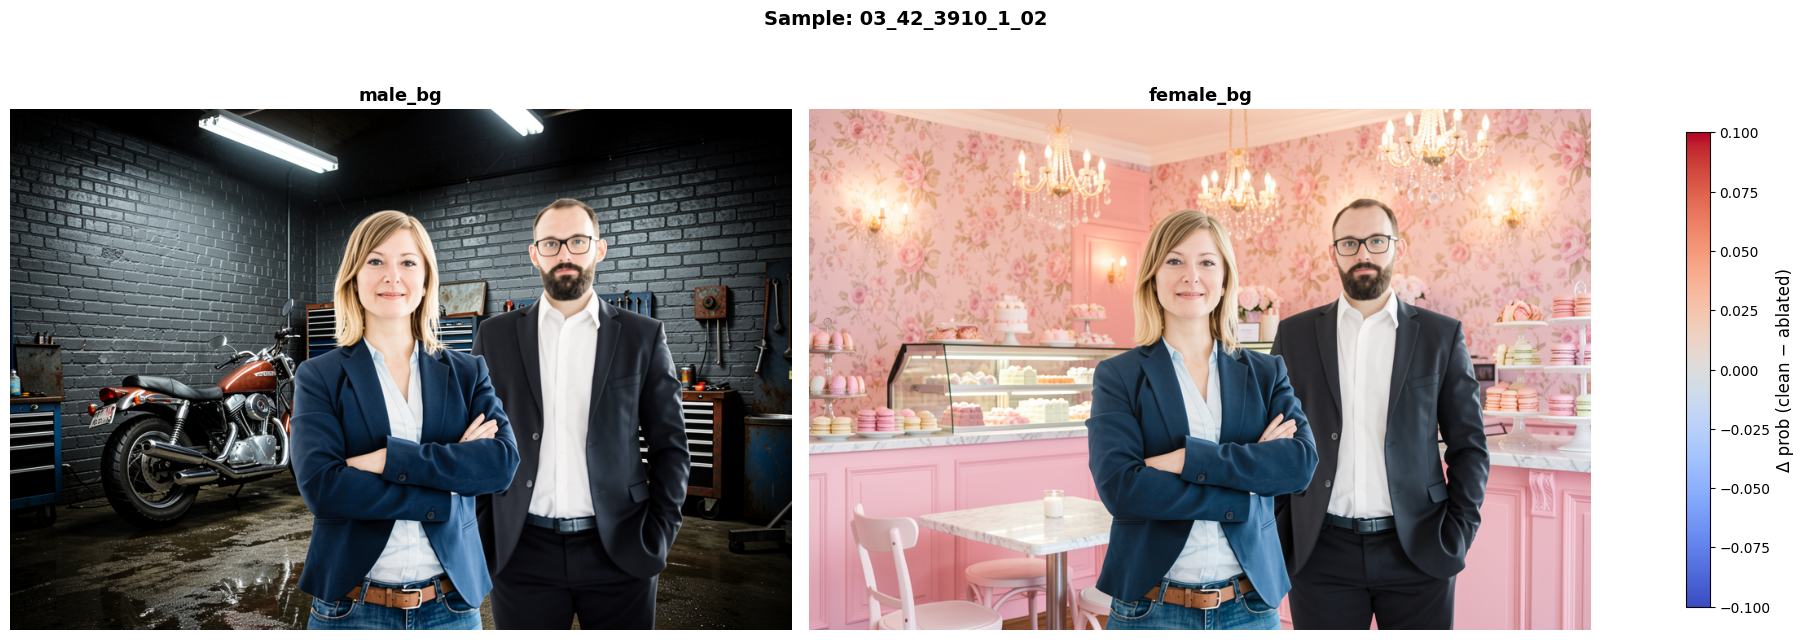

In [47]:
plot_sample_comparison("03_42_3910_1_02", df1, df2)

In [45]:
df1["sample_id"].unique()[-10:]

array(['03_42_3910_1_02', '03_27_0938_1_02', '03_26_0798_1_01',
       '03_48_5238_1_02', '03_27_0886_1_02', '03_40_3502_1_02',
       '03_46_4866_1_03', '03_48_5202_1_03', '03_06_0046_1_03',
       '03_31_1682_1_01'], dtype=object)

In [12]:
print("Style 1 delta range:", df1['delta'].min(), df1['delta'].max())
print("Style 2 delta range:", df2['delta'].min(), df2['delta'].max())
print("Style 1 percentiles:", np.percentile(df1['delta'], [1, 5, 25, 50, 75, 95, 99]))
print("Style 2 percentiles:", np.percentile(df2['delta'], [1, 5, 25, 50, 75, 95, 99]))

Style 1 delta range: -0.38671875 0.985809326171875
Style 2 delta range: -0.37890625 0.89697265625
Style 1 percentiles: [-0.26171875 -0.07402344  0.          0.          0.          0.16796875
  0.60313202]
Style 2 percentiles: [-0.20703125 -0.0625      0.          0.          0.          0.1171875
  0.41476563]


In [17]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3242 entries, 0 to 3241
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        3242 non-null   object 
 1   variant          3242 non-null   object 
 2   grid_h           3242 non-null   int64  
 3   grid_w           3242 non-null   int64  
 4   win_size         3242 non-null   int64  
 5   frac             3242 non-null   float64
 6   stride           3242 non-null   int64  
 7   win_row          3242 non-null   int64  
 8   win_col          3242 non-null   int64  
 9   clean_probs      3242 non-null   object 
 10  text-only_probs  3242 non-null   object 
 11  ablated-probs    3242 non-null   object 
 12  correct_answer   3242 non-null   object 
 13  clean_top1       3242 non-null   object 
 14  ablated_top1     3242 non-null   object 
 15  flipped          3242 non-null   bool   
 16  delta            3242 non-null   float64
dtypes: bool(1), fl

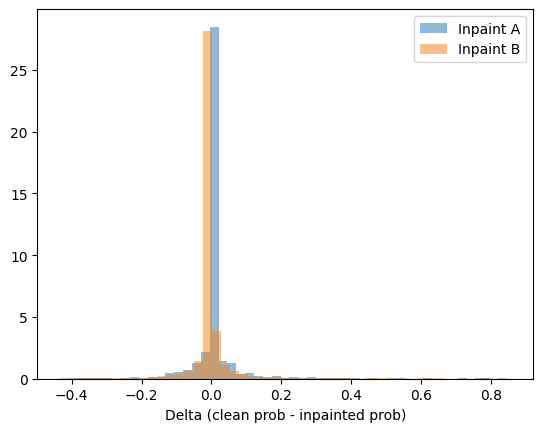

Mann-Whitney U: stat=8655561.00, p=8.0378e-09


In [48]:
male_deltas = df1['delta']
female_deltas = df2['delta']
fig, ax = plt.subplots()
ax.hist(male_deltas, bins=50, alpha=0.5, label='Inpaint A', density=True)
ax.hist(female_deltas, bins=50, alpha=0.5, label='Inpaint B', density=True)
ax.set_xlabel('Delta (clean prob - inpainted prob)')
ax.legend()
plt.show()

# Statistical test
stat, p = stats.mannwhitneyu(male_deltas, female_deltas, alternative='two-sided')
print(f"Mann-Whitney U: stat={stat:.2f}, p={p:.4e}")

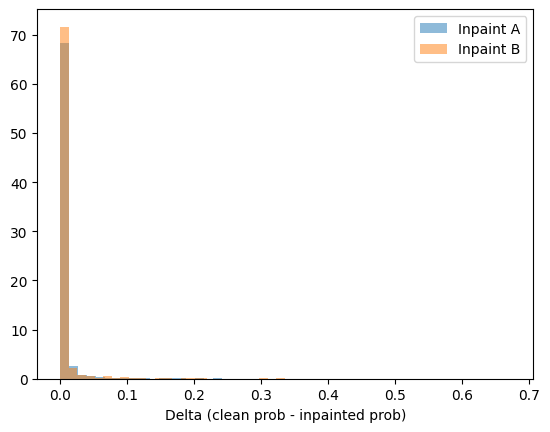

Mann-Whitney U: stat=8821073.50, p=1.4871e-11


In [10]:
male_jsds = df1['jsd']
female_jsds = df2['jsd']
fig, ax = plt.subplots()
ax.hist(male_jsds, bins=50, alpha=0.5, label='Inpaint A', density=True)
ax.hist(female_jsds, bins=50, alpha=0.5, label='Inpaint B', density=True)
ax.set_xlabel('Delta (clean prob - inpainted prob)')
ax.legend()
plt.show()

# Statistical test
stat, p = stats.mannwhitneyu(male_jsds, female_jsds, alternative='two-sided')
print(f"Mann-Whitney U: stat={stat:.2f}, p={p:.4e}")

In [49]:
# Top 90 and bottom 10 deltas (male_bg)
top90_male = df1.nlargest(90, 'delta')
bottom10_male = df1.nsmallest(10, 'delta')

# Top 90 and bottom 10 deltas (female_bg)
top90_female = df2.nlargest(90, 'delta')
bottom10_female = df2.nsmallest(10, 'delta')

# Optional: show key columns
display(top90_male[['sample_id', 'win_row', 'win_col', 'delta']])
display(bottom10_male[['sample_id', 'win_row', 'win_col', 'delta']])

display(top90_female[['sample_id', 'win_row', 'win_col', 'delta']])
display(bottom10_female[['sample_id', 'win_row', 'win_col', 'delta']])

,sample_id,win_row,win_col,delta
3863,03_40_3502_1_02,15,30,0.856445
1577,03_13_0310_1_01,2,12,0.795815
1585,03_13_0310_1_01,4,12,0.794281
1593,03_13_0310_1_01,6,12,0.788940
3862,03_40_3502_1_02,15,25,0.783203
...,...,...,...,...
1379,03_02_0010_1_03,8,16,0.230469
2585,03_48_5170_1_03,6,3,0.230469
2591,03_48_5170_1_03,9,0,0.228516
1277,03_42_3970_1_02,9,3,0.226562


,sample_id,win_row,win_col,delta
279,03_31_1746_1_02,5,5,-0.410156
762,03_37_2942_1_02,0,0,-0.402344
2596,03_48_5170_1_03,9,15,-0.380859
2043,03_40_3622_1_03,5,25,-0.378906
2871,03_27_0902_1_02,6,15,-0.359375
2880,03_27_0902_1_02,9,15,-0.359375
272,03_31_1746_1_02,0,5,-0.355469
2595,03_48_5170_1_03,9,12,-0.353516
2870,03_27_0902_1_02,6,12,-0.347656
2879,03_27_0902_1_02,9,12,-0.347656


,sample_id,win_row,win_col,delta
1648,03_26_0726_1_03,6,14,0.845459
1647,03_26_0726_1_03,6,12,0.825928
1638,03_26_0726_1_03,4,14,0.818359
840,03_48_5126_1_03,6,15,0.793945
1637,03_26_0726_1_03,4,12,0.793457
...,...,...,...,...
2342,03_48_5166_1_02,0,0,0.222656
70,03_23_0654_1_01,16,48,0.216797
1649,03_26_0726_1_03,6,16,0.207031
17,03_45_4574_1_01,4,2,0.203125


,sample_id,win_row,win_col,delta
66,03_23_0654_1_01,16,16,-0.433594
67,03_23_0654_1_01,16,24,-0.417969
4012,03_31_1682_1_01,3,12,-0.380859
3153,03_40_3526_1_02,8,4,-0.367188
58,03_23_0654_1_01,8,16,-0.359375
74,03_23_0654_1_01,24,16,-0.359375
59,03_23_0654_1_01,8,24,-0.351562
3152,03_40_3526_1_02,8,0,-0.339844
2043,03_40_3622_1_03,5,25,-0.332031
2050,03_40_3622_1_03,10,25,-0.324219


In [50]:
cases = {
    "top90_male": top90_male,
    "bottom10_male": bottom10_male,
    "top90_female": top90_female,
    "bottom10_female": bottom10_female,
}

rows = []
for case_name, case_df in cases.items():
    ids = case_df["sample_id"].drop_duplicates().sort_values().reset_index(drop=True)
    rows.extend([{"case": case_name, "sample_id": sid} for sid in ids])

combined_ids_df = pd.DataFrame(rows)
combined_ids_df.head()

,case,sample_id
0,top90_male,03_02_0010_1_03
1,top90_male,03_06_0046_1_03
2,top90_male,03_13_0310_1_01
3,top90_male,03_23_0654_1_01
4,top90_male,03_23_0654_1_02


In [51]:
combined_ids_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   case       57 non-null     object
 1   sample_id  57 non-null     object
dtypes: object(2)
memory usage: 1.0+ KB


In [52]:
print(top90_male['sample_id'].nunique() == (combined_ids_df['case'] == 'top90_male').sum())
print(top90_female['sample_id'].nunique() == (combined_ids_df['case'] == 'top90_female').sum())
print(bottom10_male['sample_id'].nunique() == (combined_ids_df['case'] == 'bottom10_male').sum())
print(bottom10_female['sample_id'].nunique() == (combined_ids_df['case'] == 'bottom10_female').sum())

True
True
True
True


In [53]:
SAVE_DIR = Path('/weka/eickhoff/esx139/patch_analysis/sliding_window/analyze_results/heatmaps/polarity1/extreme_deltas')

for idx, row in combined_ids_df.iterrows():
    sample_id = row['sample_id']
    case = row['case'].split('_')[-1]  # e.g. "male"
    fig, axes = plot_sample_comparison(sample_id, df1, df2)
    save_path = SAVE_DIR / sample_id / f"{case}.png"
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path)
    plt.close(fig)